In [1]:
# ==========================================
# CELL 1: SETUP, IMPORTS & CONFIGURATION
# Run this first every session.
# ==========================================
import torch
import zipfile, os, json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from config import GPTConfig
from tokenizer import BPETokenizer
from model import GPT

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {device}")

config = GPTConfig.from_toml('config.toml')
assert config.block_size == 512, "ERROR: Teacher said DO NOT change block_size!"

tokenizer = BPETokenizer()
tokenizer.load('merges.json')
print("📚 Config and Tokenizer ready.")

# ---- Dataset Classes ----

class PreTokenizedDataset(Dataset):
    def __init__(self, tokens, block_size):
        self.tokens, self.block_size = tokens, block_size
    def __len__(self): return len(self.tokens) - self.block_size
    def __getitem__(self, idx):
        chunk = self.tokens[idx : idx + self.block_size + 1]
        return chunk[:-1], chunk[1:]

class TinyStoriesDataset(Dataset):
    def __init__(self, zip_path, file_name, tokenizer, block_size, max_stories):
        self.block_size = block_size
        tokens, n = [], 0
        with zipfile.ZipFile(zip_path) as z, z.open(file_name) as f:
            for line in f:
                if not line.strip(): continue
                tokens.extend(tokenizer._encode_chunk(line))
                n += 1
                if n % 10000 == 0: print(f"  ...{n}/{max_stories} stories")
                if n >= max_stories: break
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        print(f"✅ {len(self.tokens)} tokens from {n} stories.")
    def __len__(self): return len(self.tokens) - self.block_size
    def __getitem__(self, idx):
        chunk = self.tokens[idx : idx + self.block_size + 1]
        return chunk[:-1], chunk[1:]

# ---- Shared Helper Functions ----

def estimate_loss(model, loader, eval_iters=10):
    model.eval()
    losses = torch.zeros(eval_iters)
    with torch.no_grad():
        for i, (X, Y) in enumerate(loader):
            if i >= eval_iters: break
            _, loss = model(X.to(device), targets=Y.to(device))
            losses[i] = loss.item()
    model.train()
    return losses.mean().item()

def estimate_loss_and_acc(model, loader, eval_iters=20):
    model.eval()
    losses, accs = torch.zeros(eval_iters), torch.zeros(eval_iters)
    with torch.no_grad():
        for i, (X, Y) in enumerate(loader):
            if i >= eval_iters: break
            X, Y = X.to(device), Y.to(device)
            logits, loss = model(X, targets=Y)
            losses[i] = loss.item()
            accs[i]   = (logits.argmax(-1) == Y).float().mean()
    model.train()
    return losses.mean().item(), accs.mean().item()

🖥️  Device: cpu
📚 Config and Tokenizer ready.


In [3]:
# ==========================================
# CELL 2: HYPERPARAMETER TUNING
# ==========================================

train_pt, val_pt = 'pretokenized_train_200k.pt', 'pretokenized_val_5k.pt'

if os.path.exists(train_pt) and os.path.exists(val_pt):
    print("📂 Loading pre-tokenized files instantly...")
    train_dataset = PreTokenizedDataset(torch.load(train_pt), config.block_size)
    val_dataset   = PreTokenizedDataset(torch.load(val_pt),   config.block_size)
else:
    print("⚠️  Pre-tokenized files missing — tokenizing from scratch...")
    train_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_train.txt', tokenizer, config.block_size, max_stories=65000)
    val_dataset   = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_val.txt',   tokenizer, config.block_size, max_stories=2000)

# Trial 5 removed — ran OOM on SLURM, weights not saved
trials = [
    {"name": "Trial_1_Baseline",     "lr": 3e-4, "batch_size": 32, "weight_decay": 0.10},
    {"name": "Trial_2_Fast_Learner", "lr": 1e-3, "batch_size": 32, "weight_decay": 0.10},
    {"name": "Trial_3_High_Reg",     "lr": 5e-4, "batch_size": 16, "weight_decay": 0.20},
    {"name": "Trial_4_Conservative", "lr": 1e-4, "batch_size": 32, "weight_decay": 0.05},
]

max_iters, eval_interval = 2000, 250
stats_json = os.path.join(output_dir, "all_tuning_stats.json")
all_trials_stats = json.load(open(stats_json)) if os.path.exists(stats_json) else {}

for trial in trials:
    save_path = os.path.join(output_dir, f"{trial['name']}_best.pt")

    if os.path.exists(save_path):
        print(f"⏭️  Skipping {trial['name']} — weights already exist.")
        continue

    print(f"\n{'='*50}\n🚀 {trial['name']}  LR={trial['lr']} | Batch={trial['batch_size']} | WD={trial['weight_decay']}\n{'='*50}")

    train_loader = DataLoader(train_dataset, batch_size=trial['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=trial['batch_size'], shuffle=False)
    train_iter   = iter(train_loader)

    model = GPT(config).to(device)
    optimizer = model.configure_optimizers(learning_rate=trial['lr'], weight_decay=trial['weight_decay'])
    model.train()

    best_val_loss, history = float('inf'), []

    for step in range(max_iters):
        try: xb, yb = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            xb, yb = next(train_iter)

        _, loss = model(xb.to(device), targets=yb.to(device))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == max_iters - 1:
            val_loss = estimate_loss(model, val_loader)
            print(f"  Step {step:04d} | Train: {loss.item():.4f} | Val: {val_loss:.4f}")
            history.append({"step": step, "train_loss": loss.item(), "val_loss": val_loss})
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), save_path)
                print(f"  💾 New best saved → {save_path}")

    all_trials_stats[trial['name']] = {"best_val_loss": best_val_loss, "history": history}
    print(f"✅ Done — Best Val Loss: {best_val_loss:.4f}")

# JSON missing (SLURM run never saved it) — reconstruct from saved weights
if not all_trials_stats:
    print("📊 JSON missing — reconstructing best_val_loss from saved weights...")
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    for trial in trials:
        pt = os.path.join(output_dir, f"{trial['name']}_best.pt")
        m = GPT(config).to(device)
        m.load_state_dict(torch.load(pt, map_location=device))
        val_loss = estimate_loss(m, val_loader, eval_iters=10)
        all_trials_stats[trial['name']] = {"best_val_loss": val_loss, "history": []}
        print(f"  {trial['name']}: {val_loss:.4f}")

best_trial = min(all_trials_stats, key=lambda k: all_trials_stats[k]["best_val_loss"])
print(f"\n🏆 Best: {best_trial}")
for name, s in all_trials_stats.items():
    print(f"  {name}: {s['best_val_loss']:.4f}")

with open(stats_json, "w") as f:
    json.dump(all_trials_stats, f, indent=4)
print(f"📊 Saved → {stats_json}")

📂 Loading pre-tokenized files instantly...
⏭️  Skipping Trial_1_Baseline — weights already exist.
⏭️  Skipping Trial_2_Fast_Learner — weights already exist.
⏭️  Skipping Trial_3_High_Reg — weights already exist.
⏭️  Skipping Trial_4_Conservative — weights already exist.
📊 JSON missing — reconstructing best_val_loss from saved weights...
number of parameters: 60.24M
  Trial_1_Baseline: 1.5534
number of parameters: 60.24M
  Trial_2_Fast_Learner: 1.7112
number of parameters: 60.24M


KeyboardInterrupt: 

In [3]:
# ==========================================
# CELL 3: ARCHITECTURE COMPARISON TRAINING
# ==========================================
train_pt, val_pt = 'pretokenized_train_200k.pt', 'pretokenized_val_5k.pt'

if os.path.exists(train_pt) and os.path.exists(val_pt):
    print("📂 Loading pre-tokenized files...")
    train_dataset = PreTokenizedDataset(torch.load(train_pt), config.block_size)
    val_dataset   = PreTokenizedDataset(torch.load(val_pt),   config.block_size)
else:
    print("⚠️  Tokenizing from scratch (will cache for next run)...")
    train_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_train.txt', tokenizer, config.block_size, max_stories=200000)
    val_dataset   = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_val.txt',   tokenizer, config.block_size, max_stories=5000)
    torch.save(train_dataset.tokens, train_pt)
    torch.save(val_dataset.tokens,   val_pt)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

# ---- Architecture Definitions ----
def _cfg(**kwargs):
    c = GPTConfig.from_toml('config.toml')
    for k, v in kwargs.items(): setattr(c, k, v)
    return c

arch_configs = {
    "Arch_1_Baseline":     _cfg(embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    "Arch_2_Deep_Narrow":  _cfg(n_layer=8, n_head=4, n_embd=256, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    "Arch_3_Shallow_Wide": _cfg(n_layer=4, n_head=8, n_embd=512, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    "Arch_4_High_Dropout": _cfg(embd_pdrop=0.3, resid_pdrop=0.3, attn_pdrop=0.3),
}

# ---- Training Loop ----
max_iters, eval_interval, accumulation_steps = 5000, 500, 8
stats_file = os.path.join(output_dir, "architecture_comparison_stats.json")
all_arch_stats = json.load(open(stats_file)) if os.path.exists(stats_file) else {}

for arch_name, a_config in arch_configs.items():
    if arch_name in all_arch_stats and len(all_arch_stats[arch_name]["step"]) >= max_iters // eval_interval:
        print(f"⏭️  Skipping {arch_name} (already complete).")
        continue

    print(f"\n{'='*50}\n🧠 {arch_name}  L={a_config.n_layer} H={a_config.n_head} E={a_config.n_embd} D={a_config.embd_pdrop}\n{'='*50}")

    model = GPT(a_config).to(device)
    optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=3e-4, betas=(0.9, 0.95))
    train_iter = iter(train_loader)
    history = {"step": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    optimizer.zero_grad(set_to_none=True)

    for step in range(max_iters):
        loss_accum = acc_accum = 0.0
        for _ in range(accumulation_steps):
            try: xb, yb = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                xb, yb = next(train_iter)
            xb, yb = xb.to(device), yb.to(device)
            logits, loss = model(xb, targets=yb)
            (loss / accumulation_steps).backward()
            loss_accum += loss.item()
            acc_accum  += (logits.argmax(-1) == yb).float().mean().item()

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        if step % eval_interval == 0 or step == max_iters - 1:
            val_loss, val_acc = estimate_loss_and_acc(model, val_loader, eval_iters=120)
            train_loss = loss_accum / accumulation_steps
            train_acc  = acc_accum  / accumulation_steps
            print(f"  Step {step:04d} | Train {train_loss:.4f} ({train_acc:.4f}) | Val {val_loss:.4f} ({val_acc:.4f})")
            for k, v in zip(["step","train_loss","val_loss","train_acc","val_acc"],
                             [step, train_loss, val_loss, train_acc, val_acc]):
                history[k].append(v)
            all_arch_stats[arch_name] = history
            with open(stats_file, "w") as f: json.dump(all_arch_stats, f, indent=4)

    torch.save(model.state_dict(), os.path.join(output_dir, f"{arch_name}_weights.pt"))
    print(f"✅ {arch_name} complete.")

print(f"\n🎉 All architectures trained. Stats in {stats_file}.")

📂 Loading pre-tokenized files...
⏭️  Skipping Arch_1_Baseline (already complete).
⏭️  Skipping Arch_2_Deep_Narrow (already complete).
⏭️  Skipping Arch_3_Shallow_Wide (already complete).
⏭️  Skipping Arch_4_High_Dropout (already complete).

🎉 All architectures trained. Stats in output/architecture_comparison_stats.json.


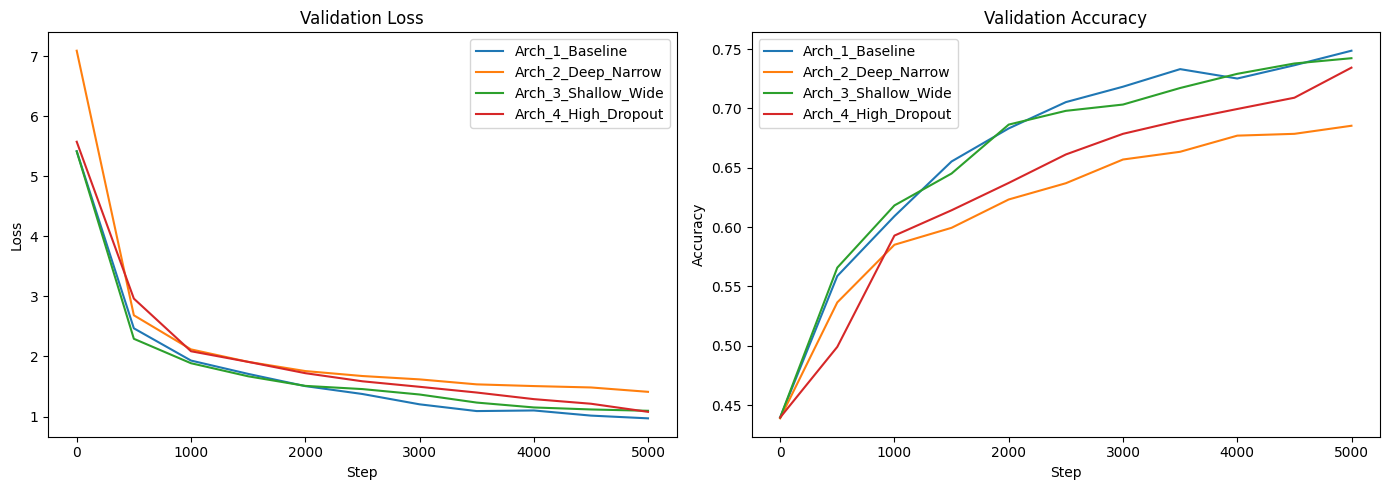

✅ Saved → val_loss_comparison.png


: 

In [ ]:
# ==========================================
# CELL 4: PLOT ALL MODELS
# ==========================================
data = json.load(open('output/architecture_comparison_stats.json'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, stats in data.items():
    ax1.plot(stats['step'], stats['val_loss'], label=name)
    ax2.plot(stats['step'], stats['val_acc'],  label=name)

ax1.set(title="Validation Loss",     xlabel="Step", ylabel="Loss")
ax2.set(title="Validation Accuracy", xlabel="Step", ylabel="Accuracy")
ax1.legend(); ax2.legend()

plt.tight_layout()
plt.savefig("val_loss_comparison.png", dpi=150)   # root, matches existing file
plt.show()
print("✅ Saved → val_loss_comparison.png")

In [ ]:
# ==========================================
# CELL 5: LOAD BEST MODEL + GENERATE 5 STORIES
# Requires Cell 1. Standalone — rebuilds arch_configs locally.
# ==========================================

torch.manual_seed(42) # Set any constant number
torch.cuda.manual_seed_all(42)

# Rebuild arch_configs (mirrors Cell 3, no retraining)
def _cfg(**kwargs):
    c = GPTConfig.from_toml('config.toml')
    for k, v in kwargs.items(): setattr(c, k, v)
    return c

arch_configs = {
    "Arch_1_Baseline":     _cfg(embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    "Arch_2_Deep_Narrow":  _cfg(n_layer=8, n_head=4, n_embd=256, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    "Arch_3_Shallow_Wide": _cfg(n_layer=4, n_head=8, n_embd=512, embd_pdrop=0.1, resid_pdrop=0.1, attn_pdrop=0.1),
    "Arch_4_High_Dropout": _cfg(embd_pdrop=0.3, resid_pdrop=0.3, attn_pdrop=0.3),
}

# Auto-select best arch from saved stats
data = json.load(open('output/architecture_comparison_stats.json'))
best_arch = min(data, key=lambda k: min(data[k]['val_loss']))
print(f"🏆 Best arch: {best_arch}  (best val_loss = {min(data[best_arch]['val_loss']):.4f})")

best_model = GPT(arch_configs[best_arch]).to(device)
best_model.load_state_dict(
    torch.load(f'output/{best_arch}_weights.pt', map_location=device)
)
best_model.eval()
print(f"✅ Loaded weights from output/{best_arch}_weights.pt\n")

# Generation using model's built-in .generate()
def generate_story(prompt, max_new_tokens=200, temperature=0.8, top_k=50):
    ids = tokenizer.encode(prompt)          # str → list[int]  (NOT _encode_chunk — that takes bytes)
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    with torch.no_grad():
        out = best_model.generate(idx, max_new_tokens=max_new_tokens,
                                  temperature=temperature, do_sample=True, top_k=top_k)
    # Decode the full text and strip trailing whitespace
    story = tokenizer.decode(out[0].tolist()).rstrip()
    
    # Slice off everything after the absolute last period
    if '.' in story:
        story = story[:story.rfind('.') + 1]
        
    return story

prompts = [
    "Once upon a time",
    "In a small village",
    "There was a little dragon",
    "The sun was setting when",
    "A brave rabbit named Shuki",
]

for i, prompt in enumerate(prompts, 1):
    print(f"--- Story {i} ---")
    print(generate_story(prompt))
    print()

🏆 Best arch: Arch_1_Baseline  (best val_loss = 0.9700)
number of parameters: 60.24M
✅ Loaded weights from output/Arch_1_Baseline_weights.pt

--- Story 1 ---


: 